# Phase 1 : Configuration and Ingestion

#### Predict whether an AREA will be HIGH-CRIME or LOW-CRIME next week

In [1]:
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    accuracy_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

In [2]:
# Set random seeds for reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
# Load and explore the dataset

import os
import requests
import pandas as pd

# Create 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')
    print("Directory 'data' created.")

# LAPD Crime Data API Endpoint (Crime from 2020 to Present)
DATA_URL = "https://data.lacity.org/api/views/2nrs-mtv8/rows.csv?accessType=DOWNLOAD"
DATA_PATH = "data/lapd_crime_data.csv"

def download_data(url, save_path):
    print("Starting download!!")
    response = requests.get(url)
    if response.status_code == 200:
        with open(save_path, 'wb') as f:
            f.write(response.content)
        print(f"Data successfully saved to {save_path}")
    else:
        print(f"Failed to download data. Status code: {response.status_code}")

# Execute the download
if not os.path.exists(DATA_PATH):
    download_data(DATA_URL, DATA_PATH)
else:
    print("Data file already exists.")

# Quick Load to verify
df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded. Total rows: {len(df)}")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Data file already exists.
Dataset loaded. Total rows: 1004894
Shape: (1004894, 28)
Columns: ['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc', 'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT', 'LON']


# Phase 2 : Temporal Harmonization and Reporting-Lag Mitigation

#### Cleaning and Trimming

In [4]:
# Basic data cleaning and feature engineering

if "date_occ" not in df.columns:
    df["date_occ"] = pd.to_datetime(df["DATE OCC"], errors="coerce")
else:
    df["date_occ"] = pd.to_datetime(df["date_occ"], errors="coerce")

df = df.dropna(subset=["date_occ", "AREA NAME"]).copy()

for col in ["Vict Age", "occ_hour", "occ_hour_filled", "is_weekend"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "is_weekend" not in df.columns:
    df["is_weekend"] = (df["date_occ"].dt.weekday >= 5).astype(int)
else:
    df["is_weekend"] = df["is_weekend"].fillna(0).astype(int)

if "occ_hour_filled" in df.columns:
    hour_col = "occ_hour_filled"
elif "occ_hour" in df.columns:
    hour_col = "occ_hour"
else:
    hour_col = None

if "time_bucket" not in df.columns:
    def make_bucket(h):
        if pd.isna(h):
            return "Unknown"
        h = int(h)
        if 5 <= h < 12:
            return "Morning"
        elif 12 <= h < 17:
            return "Afternoon"
        elif 17 <= h < 21:
            return "Evening"
        else:
            return "Night"

    if hour_col is not None:
        df["time_bucket"] = df[hour_col].apply(make_bucket)
    else:
        df["time_bucket"] = "Unknown"

df["week_start"] = df["date_occ"] - pd.to_timedelta(df["date_occ"].dt.weekday, unit="D")
df["week_start"] = pd.to_datetime(df["week_start"])

In [5]:
# Reporting-lag / Incomplete-tail handling

city_weekly = df.groupby("week_start").size().sort_index()

rolling_med_8 = city_weekly.rolling(8, min_periods=4).median().shift(1)
ratio_to_recent = city_weekly / rolling_med_8

bad_week = ((ratio_to_recent < 0.60) & rolling_med_8.notna()).astype(int)
bad_run = bad_week.rolling(4, min_periods=4).sum()
collapse_start = bad_run[bad_run >= 3].index.min()

if pd.notna(collapse_start):
    reliable_end = collapse_start - pd.Timedelta(days=7)
else:
    reliable_end = city_weekly.index.max()

df = df[df["week_start"] <= reliable_end].copy()

print("Reliable end week used for modeling:", reliable_end.date())
print("Rows after lag trimming:", df.shape)

Reliable end week used for modeling: 2024-12-23
Rows after lag trimming: (1004886, 32)


# Phase 3 : Exploratory Data Analysis and Spatial Visualization

#### Visualizing Temporal and Spatial Trends

### 1. Crime Volume by Area

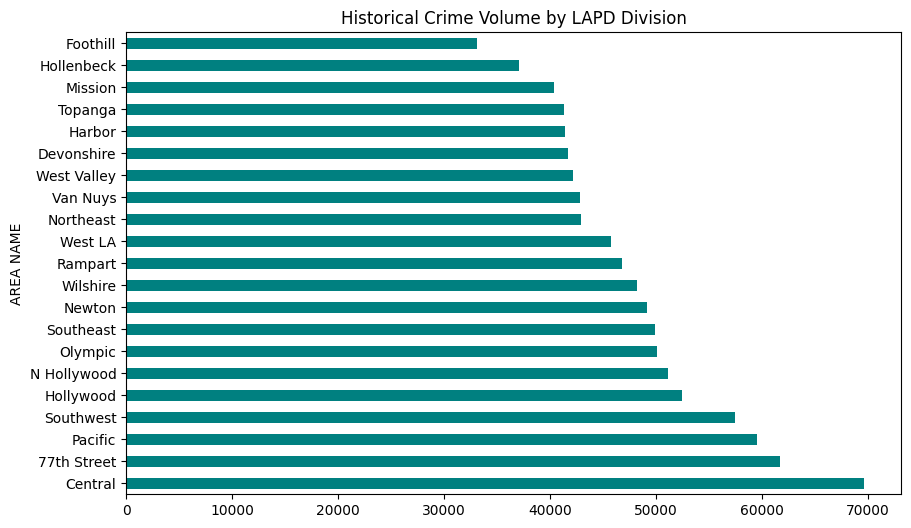

In [6]:
# Spatial Hotspots
plt.figure(figsize=(10, 6))
df['AREA NAME'].value_counts().plot(kind='barh', color='teal')
plt.title("Historical Crime Volume by LAPD Division")
plt.show()

### 2. Temporal Cycles

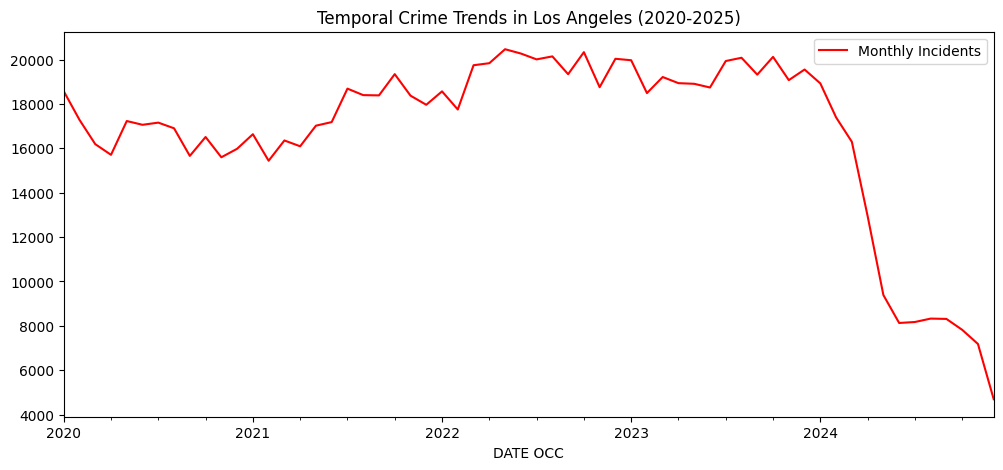

In [7]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])
plt.figure(figsize=(12, 5))
df.resample('M', on='DATE OCC').size().plot(label='Monthly Incidents', color='red')
plt.title("Temporal Crime Trends in Los Angeles (2020-2025)")
plt.legend()
plt.show()

### 3. Victim Age Distribution

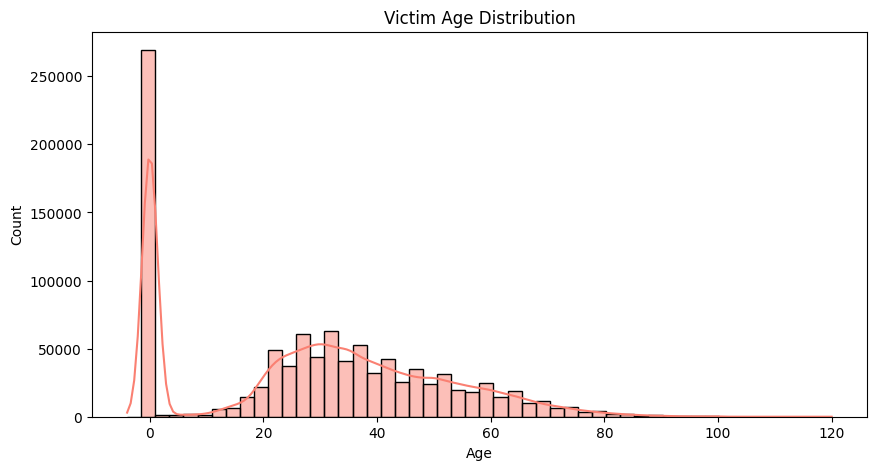

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Vict Age'].dropna(), bins=50, kde=True, color='salmon')
plt.title('Victim Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Phase 4 : Feature Synthesis and Row-Level Signal Extraction

In [9]:
if "crime_category" in df.columns:
    df["is_part1"] = (df["crime_category"].astype(str).str.upper() == "PART1").astype(int)
    df["is_part2"] = (df["crime_category"].astype(str).str.upper() == "PART2").astype(int)
elif "Part 1-2" in df.columns:
    df["is_part1"] = (pd.to_numeric(df["Part 1-2"], errors="coerce") == 1).astype(int)
    df["is_part2"] = (pd.to_numeric(df["Part 1-2"], errors="coerce") == 2).astype(int)
else:
    df["is_part1"] = 0
    df["is_part2"] = 0

serious_keywords = [
    "ASSAULT", "ROBBERY", "BURGLARY", "THEFT", "MOTOR VEHICLE", "RAPE",
    "HOMICIDE", "WEAPON", "KIDNAPPING", "ARSON", "SHOTS", "BATTERY"
]
if "Crm Cd Desc" in df.columns:
    crime_desc = df["Crm Cd Desc"].fillna("").astype(str).str.upper()
    df["is_serious"] = crime_desc.apply(lambda x: int(any(k in x for k in serious_keywords)))
else:
    df["is_serious"] = 0

df["is_night"] = df["time_bucket"].isin(["Night", "Late Night", "Evening"]).astype(int)

if "Vict Sex" in df.columns:
    vs = df["Vict Sex"].fillna("").astype(str).str.upper()
    df["vict_male"] = (vs == "M").astype(int)
    df["vict_female"] = (vs == "F").astype(int)
else:
    df["vict_male"] = 0
    df["vict_female"] = 0

if "Vict Age" in df.columns:
    df["Vict Age"] = pd.to_numeric(df["Vict Age"], errors="coerce")
    df.loc[(df["Vict Age"] < 0) | (df["Vict Age"] > 100), "Vict Age"] = np.nan
else:
    df["Vict Age"] = np.nan

# Phase 5 : Spatio-Temporal Aggregation and Target Definition

### AREA-WEEK AGGREGATION

In [10]:
weekly = (
    df.groupby(["AREA NAME", "week_start"])
      .agg(
          crimes=("DR_NO", "count"),
          part1_count=("is_part1", "sum"),
          part2_count=("is_part2", "sum"),
          serious_count=("is_serious", "sum"),
          weekend_count=("is_weekend", "sum"),
          night_count=("is_night", "sum"),
          male_victim_count=("vict_male", "sum"),
          female_victim_count=("vict_female", "sum"),
          mean_vict_age=("Vict Age", "mean"),
      )
      .reset_index()
)

all_areas = sorted(weekly["AREA NAME"].unique())
all_weeks = pd.date_range(weekly["week_start"].min(), weekly["week_start"].max(), freq="W-MON")

full_index = pd.MultiIndex.from_product(
    [all_areas, all_weeks],
    names=["AREA NAME", "week_start"]
)

weekly = (
    weekly.set_index(["AREA NAME", "week_start"])
          .reindex(full_index)
          .reset_index()
)

count_cols = [
    "crimes", "part1_count", "part2_count", "serious_count",
    "weekend_count", "night_count", "male_victim_count", "female_victim_count"
]

for c in count_cols:
    weekly[c] = weekly[c].fillna(0)

weekly["mean_vict_age"] = weekly["mean_vict_age"].fillna(0)

### DERIVED FEATURES

In [11]:
weekly["part1_share"] = np.where(weekly["crimes"] > 0, weekly["part1_count"] / weekly["crimes"], 0)
weekly["part2_share"] = np.where(weekly["crimes"] > 0, weekly["part2_count"] / weekly["crimes"], 0)
weekly["serious_share"] = np.where(weekly["crimes"] > 0, weekly["serious_count"] / weekly["crimes"], 0)
weekly["weekend_share"] = np.where(weekly["crimes"] > 0, weekly["weekend_count"] / weekly["crimes"], 0)
weekly["night_share"] = np.where(weekly["crimes"] > 0, weekly["night_count"] / weekly["crimes"], 0)
weekly["male_share"] = np.where(weekly["crimes"] > 0, weekly["male_victim_count"] / weekly["crimes"], 0)
weekly["female_share"] = np.where(weekly["crimes"] > 0, weekly["female_victim_count"] / weekly["crimes"], 0)

city_total = weekly.groupby("week_start")["crimes"].sum().rename("city_total_crimes")
weekly = weekly.merge(city_total, on="week_start", how="left")
weekly["city_share"] = np.where(weekly["city_total_crimes"] > 0, weekly["crimes"] / weekly["city_total_crimes"], 0)

weekly["rank_within_week"] = weekly.groupby("week_start")["crimes"].rank(method="dense", ascending=False)
weekly["pct_rank_within_week"] = weekly.groupby("week_start")["crimes"].rank(method="average", pct=True, ascending=False)

weekly["week_of_year"] = weekly["week_start"].dt.isocalendar().week.astype(int)
weekly["month"] = weekly["week_start"].dt.month.astype(int)
weekly["quarter"] = weekly["week_start"].dt.quarter.astype(int)

weekly["week_sin"] = np.sin(2 * np.pi * weekly["week_of_year"] / 52)
weekly["week_cos"] = np.cos(2 * np.pi * weekly["week_of_year"] / 52)
weekly["month_sin"] = np.sin(2 * np.pi * weekly["month"] / 12)
weekly["month_cos"] = np.cos(2 * np.pi * weekly["month"] / 12)

### AREA BASELINE FEATURES

In [12]:
weekly = weekly.sort_values(["AREA NAME", "week_start"]).reset_index(drop=True)
group = weekly.groupby("AREA NAME")

weekly["area_avg_crimes_so_far"] = group["crimes"].transform(lambda s: s.shift(1).expanding().mean())
weekly["area_avg_city_share_so_far"] = group["city_share"].transform(lambda s: s.shift(1).expanding().mean())
weekly["area_avg_serious_share_so_far"] = group["serious_share"].transform(lambda s: s.shift(1).expanding().mean())

weekly["area_avg_crimes_so_far"] = weekly["area_avg_crimes_so_far"].fillna(0)
weekly["area_avg_city_share_so_far"] = weekly["area_avg_city_share_so_far"].fillna(0)
weekly["area_avg_serious_share_so_far"] = weekly["area_avg_serious_share_so_far"].fillna(0)

### TARGET: HIGH-CRIME NEXT WEEK

In [13]:
TOP_K = 5

weekly["next_week_crimes"] = group["crimes"].shift(-1)
weekly["next_week_rank"] = weekly.groupby("week_start")["next_week_crimes"].rank(
    method="dense",
    ascending=False
)
weekly["target_high_next_week"] = (weekly["next_week_rank"] <= TOP_K).astype(float)
weekly = weekly.dropna(subset=["next_week_crimes"]).copy()

# Phase 6 : Sequential Feature Engineering and Rolling Windows

####  Multi-Interval Lag and Rolling Metrics

In [14]:
# Lag / Rolling Features

group = weekly.groupby("AREA NAME")

for lag in [1, 2, 3, 4, 8, 12, 26]:
    weekly[f"crimes_lag_{lag}"] = group["crimes"].shift(lag)
    weekly[f"part1_lag_{lag}"] = group["part1_count"].shift(lag)
    weekly[f"serious_lag_{lag}"] = group["serious_count"].shift(lag)
    weekly[f"city_share_lag_{lag}"] = group["city_share"].shift(lag)
    weekly[f"rank_lag_{lag}"] = group["rank_within_week"].shift(lag)

for win in [4, 8, 12, 26]:
    weekly[f"crimes_roll{win}_mean"] = group["crimes"].transform(lambda s: s.shift(1).rolling(win).mean())
    weekly[f"crimes_roll{win}_std"] = group["crimes"].transform(lambda s: s.shift(1).rolling(win).std())
    weekly[f"city_share_roll{win}_mean"] = group["city_share"].transform(lambda s: s.shift(1).rolling(win).mean())
    weekly[f"serious_share_roll{win}_mean"] = group["serious_share"].transform(lambda s: s.shift(1).rolling(win).mean())

weekly["crimes_change_1w"] = weekly["crimes"] - weekly["crimes_lag_1"]
weekly["crimes_change_4w"] = weekly["crimes"] - weekly["crimes_lag_4"]
weekly["city_share_change_1w"] = weekly["city_share"] - weekly["city_share_lag_1"]

weekly["crime_vs_area_avg"] = np.where(
    weekly["area_avg_crimes_so_far"] > 0,
    weekly["crimes"] / weekly["area_avg_crimes_so_far"],
    0
)

weekly["city_share_vs_area_avg"] = np.where(
    weekly["area_avg_city_share_so_far"] > 0,
    weekly["city_share"] / weekly["area_avg_city_share_so_far"],
    0
)

weekly = weekly.replace([np.inf, -np.inf], np.nan).fillna(0)


# Phase 7 : Sequence Construction and Scaling Infrastructure

In [15]:
# Feature columns and target
feature_cols = [
    "crimes",
    "part1_count",
    "part2_count",
    "serious_count",
    "weekend_share",
    "night_share",
    "serious_share",
    "part1_share",
    "part2_share",
    "mean_vict_age",
    "male_share",
    "female_share",
    "city_share",
    "rank_within_week",
    "pct_rank_within_week",
    "area_avg_crimes_so_far",
    "area_avg_city_share_so_far",
    "area_avg_serious_share_so_far",
    "crime_vs_area_avg",
    "city_share_vs_area_avg",
    "week_sin", "week_cos", "month_sin", "month_cos",
    "crimes_lag_1", "crimes_lag_2", "crimes_lag_3", "crimes_lag_4", "crimes_lag_8", "crimes_lag_12", "crimes_lag_26",
    "part1_lag_1", "part1_lag_2", "part1_lag_3", "part1_lag_4", "part1_lag_8", "part1_lag_12", "part1_lag_26",
    "serious_lag_1", "serious_lag_2", "serious_lag_3", "serious_lag_4", "serious_lag_8", "serious_lag_12", "serious_lag_26",
    "city_share_lag_1", "city_share_lag_2", "city_share_lag_3", "city_share_lag_4", "city_share_lag_8", "city_share_lag_12", "city_share_lag_26",
    "rank_lag_1", "rank_lag_2", "rank_lag_3", "rank_lag_4", "rank_lag_8", "rank_lag_12", "rank_lag_26",
    "crimes_roll4_mean", "crimes_roll4_std",
    "crimes_roll8_mean", "crimes_roll8_std",
    "crimes_roll12_mean", "crimes_roll12_std",
    "crimes_roll26_mean", "crimes_roll26_std",
    "city_share_roll4_mean", "city_share_roll8_mean", "city_share_roll12_mean", "city_share_roll26_mean",
    "serious_share_roll4_mean", "serious_share_roll8_mean", "serious_share_roll12_mean", "serious_share_roll26_mean",
    "crimes_change_1w", "crimes_change_4w", "city_share_change_1w"
]

target_col = "target_high_next_week"
LOOKBACK = 26

### Dataset Preparation and Scaling

In [16]:
# Encoding, Scaling, and Train/Validation Split

train_end = pd.Timestamp("2023-12-25")
valid_end = pd.Timestamp("2024-08-26")

area_encoder = LabelEncoder()
weekly["area_id"] = area_encoder.fit_transform(weekly["AREA NAME"])

train_rows_for_scaler = weekly["week_start"] <= train_end

weekly.loc[:, feature_cols] = weekly[feature_cols].astype(float)

scaler = StandardScaler()
weekly.loc[train_rows_for_scaler, feature_cols] = scaler.fit_transform(
    weekly.loc[train_rows_for_scaler, feature_cols]
)
weekly.loc[~train_rows_for_scaler, feature_cols] = scaler.transform(
    weekly.loc[~train_rows_for_scaler, feature_cols]
)

In [17]:
# Build sequences from full data, then split by target week to avoid lookahead bias

def build_sequences_from_full(data, feature_cols, target_col, lookback=26):
    X_seq, X_area, y, meta = [], [], [], []

    for area_name, g in data.groupby("AREA NAME"):
        g = g.sort_values("week_start").reset_index(drop=True)

        for i in range(lookback, len(g)):
            seq_x = g.loc[i-lookback:i-1, feature_cols].values.astype(np.float32)
            area_id = int(g.loc[i, "area_id"])
            target = np.float32(g.loc[i, target_col])
            target_week = g.loc[i, "week_start"]

            X_seq.append(seq_x)
            X_area.append(area_id)
            y.append(target)
            meta.append((area_name, target_week))

    return (
        np.array(X_seq, dtype=np.float32),
        np.array(X_area, dtype=np.int64),
        np.array(y, dtype=np.float32),
        meta
    )

X_all, A_all, y_all, meta_all = build_sequences_from_full(
    weekly, feature_cols, target_col, LOOKBACK
)

In [18]:
# Split by target week to avoid lookahead bias

meta_df = pd.DataFrame(meta_all, columns=["AREA NAME", "target_week"])

train_mask = meta_df["target_week"] <= train_end
valid_mask = (meta_df["target_week"] > train_end) & (meta_df["target_week"] <= valid_end)
test_mask  = meta_df["target_week"] > valid_end

X_train, A_train, y_train = X_all[train_mask], A_all[train_mask], y_all[train_mask]
X_valid, A_valid, y_valid = X_all[valid_mask], A_all[valid_mask], y_all[valid_mask]
X_test,  A_test,  y_test  = X_all[test_mask],  A_all[test_mask],  y_all[test_mask]

meta_train = meta_df[train_mask].reset_index(drop=True)
meta_valid = meta_df[valid_mask].reset_index(drop=True)
meta_test  = meta_df[test_mask].reset_index(drop=True)

print("Train target weeks:", meta_train["target_week"].min(), "to", meta_train["target_week"].max())
print("Valid target weeks:", meta_valid["target_week"].min(), "to", meta_valid["target_week"].max())
print("Test target weeks :", meta_test["target_week"].min(), "to", meta_test["target_week"].max())

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)

Train target weeks: 2020-06-29 00:00:00 to 2023-12-25 00:00:00
Valid target weeks: 2024-01-01 00:00:00 to 2024-08-26 00:00:00
Test target weeks : 2024-09-02 00:00:00 to 2024-12-16 00:00:00
X_train: (3843, 26, 78)
X_valid: (735, 26, 78)
X_test : (336, 26, 78)


# Phase 8 : Attention-GRU Architecture and Focal Loss

In [19]:
# PyTorch Dataset and DataLoader with Weighted Sampling

class CrimeSeqDataset(Dataset):
    def __init__(self, X_seq, X_area, y):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.X_area = torch.tensor(X_area, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_area[idx], self.y[idx]

train_ds = CrimeSeqDataset(X_train, A_train, y_train)
valid_ds = CrimeSeqDataset(X_valid, A_valid, y_valid)
test_ds  = CrimeSeqDataset(X_test, A_test, y_test)

# Weighted sampler
class_counts = np.bincount(y_train.astype(int))
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[y_train.astype(int)]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler)
valid_loader = DataLoader(valid_ds, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

In [20]:
# Custom Focal Loss for Binary Classification

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        focal = alpha_t * (1 - pt).pow(self.gamma) * bce

        if self.reduction == "mean":
            return focal.mean()
        elif self.reduction == "sum":
            return focal.sum()
        return focal

In [21]:
# Attention GRU Model

class AttentionGRU(nn.Module):
    def __init__(
        self,
        num_areas,
        input_dim,
        area_emb_dim=12,
        hidden_dim=96,
        num_layers=2,
        dropout=0.30,
        bidirectional=True
    ):
        super().__init__()

        self.area_emb = nn.Embedding(num_areas, area_emb_dim)

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        gru_out_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.attn = nn.Sequential(
            nn.Linear(gru_out_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        self.head = nn.Sequential(
            nn.Linear(gru_out_dim + area_emb_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x_seq, x_area):
        out, _ = self.gru(x_seq)
        attn_scores = self.attn(out).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.sum(out * attn_weights.unsqueeze(-1), dim=1)

        area_vec = self.area_emb(x_area)
        x = torch.cat([context, area_vec], dim=1)
        logits = self.head(x).squeeze(1)
        return logits


# Phase 9 : Training, Validation, and Threshold Tuning

In [22]:
# Training Setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_areas = len(area_encoder.classes_)
input_dim = len(feature_cols)

model = AttentionGRU(
    num_areas=num_areas,
    input_dim=input_dim,
    area_emb_dim=12,
    hidden_dim=96,
    num_layers=2,
    dropout=0.30,
    bidirectional=True
).to(device)

criterion = BinaryFocalLoss(alpha=0.75, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

Using device: cpu


In [23]:
# Evaluation function

def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    all_probs, all_true = [], []

    with torch.no_grad():
        for x_seq, x_area, y in loader:
            x_seq = x_seq.to(device)
            x_area = x_area.to(device)
            logits = model(x_seq, x_area)
            probs = torch.sigmoid(logits)

            all_probs.extend(probs.cpu().numpy())
            all_true.extend(y.numpy())

    all_probs = np.array(all_probs)
    all_true = np.array(all_true)
    preds = (all_probs >= threshold).astype(int)

    metrics = {
        "f1": f1_score(all_true, preds, zero_division=0),
        "precision": precision_score(all_true, preds, zero_division=0),
        "recall": recall_score(all_true, preds, zero_division=0),
        "balanced_acc": balanced_accuracy_score(all_true, preds),
        "roc_auc": roc_auc_score(all_true, all_probs) if len(np.unique(all_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(all_true, all_probs) if len(np.unique(all_true)) > 1 else np.nan
    }
    return metrics, all_true, all_probs

def find_best_threshold(y_true, probs):
    thresholds = np.arange(0.10, 0.91, 0.01)
    best_t = 0.5
    best_score = -1

    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        rec = recall_score(y_true, preds, zero_division=0)
        score = f1 + 0.15 * rec

        if score > best_score:
            best_score = score
            best_t = t

    return best_t, best_score

In [24]:
best_valid_f1 = -1
best_state = None
patience = 10
patience_counter = 0
epochs = 50

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0

    for x_seq, x_area, y in train_loader:
        x_seq = x_seq.to(device)
        x_area = x_area.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x_seq, x_area)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    val_metrics, yv_raw, pv_raw = evaluate_model(model, valid_loader, threshold=0.5)
    scheduler.step(val_metrics["f1"])

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {total_loss / max(len(train_loader), 1):.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f} | "
        f"Val PR-AUC: {val_metrics['pr_auc']:.4f} | "
        f"Val ROC-AUC: {val_metrics['roc_auc']:.4f}"
    )

    if val_metrics["f1"] > best_valid_f1:
        best_valid_f1 = val_metrics["f1"]
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

gru_model = model


Epoch 01 | Train Loss: 0.0416 | Val F1: 0.5876 | Val Recall: 0.9022 | Val PR-AUC: 0.6023 | Val ROC-AUC: 0.8463
Epoch 02 | Train Loss: 0.0337 | Val F1: 0.5842 | Val Recall: 0.8859 | Val PR-AUC: 0.6089 | Val ROC-AUC: 0.8455
Epoch 03 | Train Loss: 0.0320 | Val F1: 0.5855 | Val Recall: 0.8750 | Val PR-AUC: 0.6111 | Val ROC-AUC: 0.8511
Epoch 04 | Train Loss: 0.0336 | Val F1: 0.6096 | Val Recall: 0.7554 | Val PR-AUC: 0.6167 | Val ROC-AUC: 0.8404
Epoch 05 | Train Loss: 0.0311 | Val F1: 0.5887 | Val Recall: 0.7935 | Val PR-AUC: 0.6381 | Val ROC-AUC: 0.8521
Epoch 06 | Train Loss: 0.0329 | Val F1: 0.6087 | Val Recall: 0.7609 | Val PR-AUC: 0.6132 | Val ROC-AUC: 0.8453
Epoch 07 | Train Loss: 0.0311 | Val F1: 0.6075 | Val Recall: 0.8370 | Val PR-AUC: 0.6288 | Val ROC-AUC: 0.8541
Epoch 08 | Train Loss: 0.0312 | Val F1: 0.5750 | Val Recall: 0.8641 | Val PR-AUC: 0.6297 | Val ROC-AUC: 0.8543
Epoch 09 | Train Loss: 0.0285 | Val F1: 0.6166 | Val Recall: 0.8478 | Val PR-AUC: 0.6281 | Val ROC-AUC: 0.8573
E

In [25]:
# Threshold tuning on validation set

val_metrics_default, yv, pv = evaluate_model(model, valid_loader, threshold=0.5)
best_threshold, best_score = find_best_threshold(yv, pv)

print("\nBest threshold from validation:", best_threshold)
print("Best threshold score:", best_score)

val_metrics_tuned, _, _ = evaluate_model(model, valid_loader, threshold=best_threshold)
print("\nValidation metrics with tuned threshold:")
for k, v in val_metrics_tuned.items():
    print(f"{k}: {v:.4f}")

# Final evaluation on test set

if len(X_test) == 0:
    print("\nNo test sequences were created. Reduce LOOKBACK or expand the test window.")
else:
    test_metrics, yt, pt = evaluate_model(model, test_loader, threshold=best_threshold)
    test_preds = (pt >= best_threshold).astype(int)

    print("\nTEST RESULTS")
    for k, v in test_metrics.items():
        print(f"{k}: {v:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(yt, test_preds))

    print("\nClassification Report:")
    print(classification_report(yt, test_preds, digits=4, zero_division=0))



Best threshold from validation: 0.6099999999999998
Best threshold score: 0.7426924368941357

Validation metrics with tuned threshold:
f1: 0.6269
precision: 0.5279
recall: 0.7717
balanced_acc: 0.7706
roc_auc: 0.8405
pr_auc: 0.6000

TEST RESULTS
f1: 0.6944
precision: 0.9091
recall: 0.5618
balanced_acc: 0.7708
roc_auc: 0.8373
pr_auc: 0.7598

Confusion Matrix:
[[242   5]
 [ 39  50]]

Classification Report:
              precision    recall  f1-score   support

         0.0     0.8612    0.9798    0.9167       247
         1.0     0.9091    0.5618    0.6944        89

    accuracy                         0.8690       336
   macro avg     0.8852    0.7708    0.8056       336
weighted avg     0.8739    0.8690    0.8578       336



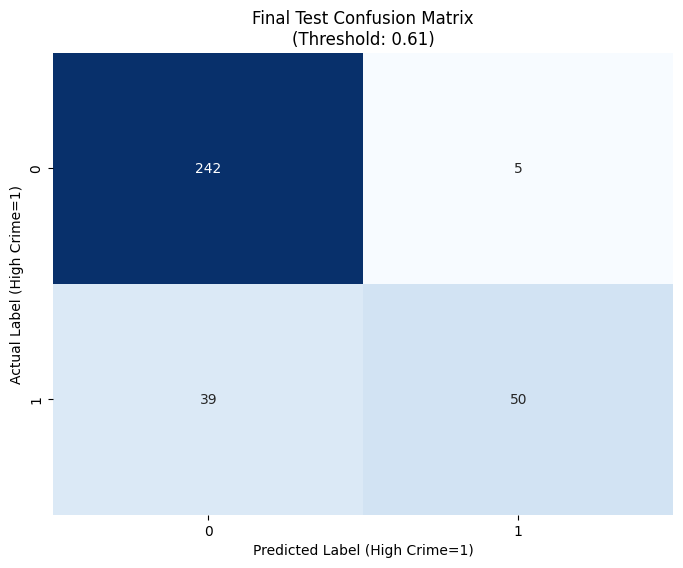

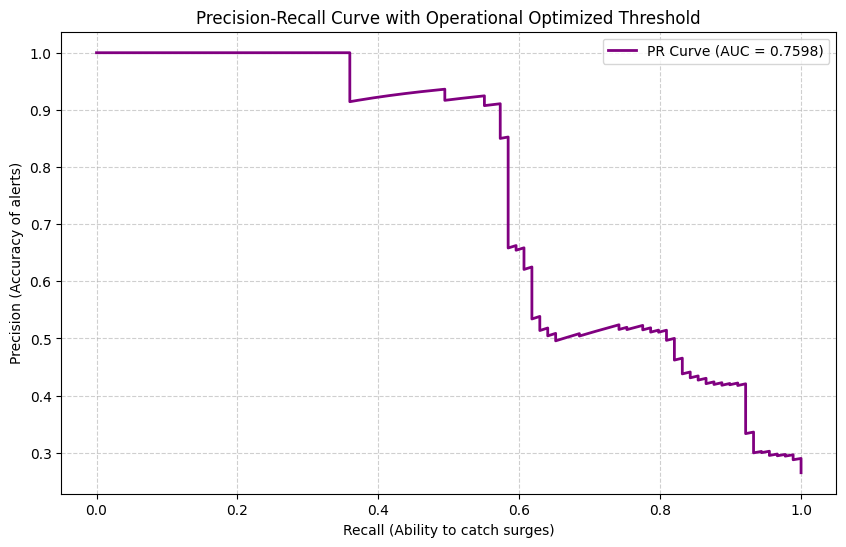

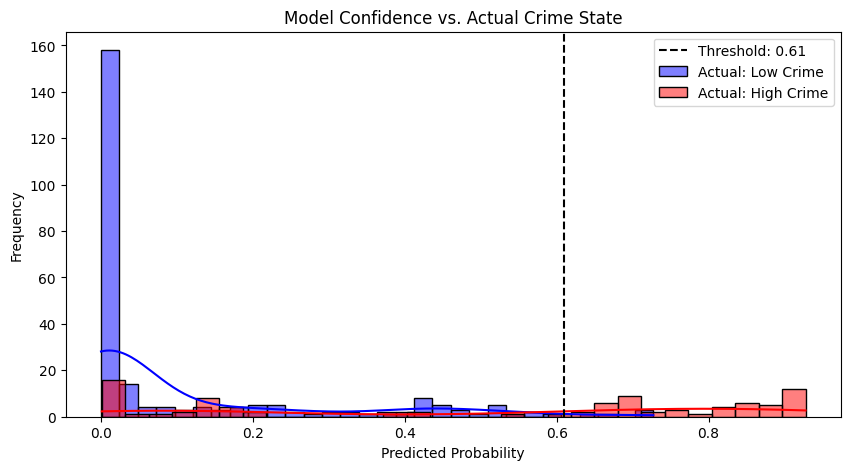

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# 1. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(yt, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Final Test Confusion Matrix\n(Threshold: {best_threshold:.2f})')
plt.xlabel('Predicted Label (High Crime=1)')
plt.ylabel('Actual Label (High Crime=1)')
plt.show()

# 2. Precision-Recall Curve (Highlighting the Best Threshold)
precision, recall, thresholds = precision_recall_curve(yt, pt)
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {test_metrics["pr_auc"]:.4f})', color='purple', lw=2)
plt.xlabel('Recall (Ability to catch surges)')
plt.ylabel('Precision (Accuracy of alerts)')
plt.title('Precision-Recall Curve with Operational Optimized Threshold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 3. Probability Distribution Analysis
plt.figure(figsize=(10, 5))
sns.histplot(pt[yt == 0], color="blue", label="Actual: Low Crime", kde=True, bins=30, alpha=0.5)
sns.histplot(pt[yt == 1], color="red", label="Actual: High Crime", kde=True, bins=30, alpha=0.5)
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Threshold: {best_threshold:.2f}')
plt.title('Model Confidence vs. Actual Crime State')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [27]:
# Next-week predictions for all areas based on latest available data

full_pred_df = weekly.copy()

latest_rows = []

for area_name, g in full_pred_df.groupby("AREA NAME"):
    g = g.sort_values("week_start").reset_index(drop=True)

    if len(g) >= LOOKBACK:
        seq_x = g.loc[len(g)-LOOKBACK:len(g)-1, feature_cols].values.astype(np.float32)
        area_id = int(g.loc[len(g)-1, "area_id"])
        last_week = g.loc[len(g)-1, "week_start"]
        latest_rows.append((area_name, seq_x, area_id, last_week))

pred_records = []

model.eval()
with torch.no_grad():
    for area_name, seq_x, area_id, last_week in latest_rows:
        x_seq = torch.tensor(seq_x, dtype=torch.float32).unsqueeze(0).to(device)
        x_area = torch.tensor([area_id], dtype=torch.long).to(device)

        prob = torch.sigmoid(model(x_seq, x_area)).item()
        pred = int(prob >= best_threshold)

        pred_records.append({
            "AREA NAME": area_name,
            "last_available_week": last_week,
            "predicted_prob_high_next_week": prob,
            "predicted_class": "High Crime" if pred == 1 else "Low Crime"
        })

pred_df = pd.DataFrame(pred_records).sort_values(
    "predicted_prob_high_next_week",
    ascending=False
).reset_index(drop=True)

print("\nTop predicted high-risk areas for next week:")
print(pred_df.head(10))


Top predicted high-risk areas for next week:
     AREA NAME last_available_week  predicted_prob_high_next_week  \
0      Central          2024-12-16                       0.929153   
1      Pacific          2024-12-16                       0.928287   
2    Southwest          2024-12-16                       0.758736   
3      Rampart          2024-12-16                       0.427737   
4      Olympic          2024-12-16                       0.345536   
5  N Hollywood          2024-12-16                       0.187159   
6     Wilshire          2024-12-16                       0.170061   
7    Hollywood          2024-12-16                       0.078725   
8    Northeast          2024-12-16                       0.050151   
9      West LA          2024-12-16                       0.028184   

  predicted_class  
0      High Crime  
1      High Crime  
2      High Crime  
3       Low Crime  
4       Low Crime  
5       Low Crime  
6       Low Crime  
7       Low Crime  
8       Low Cr

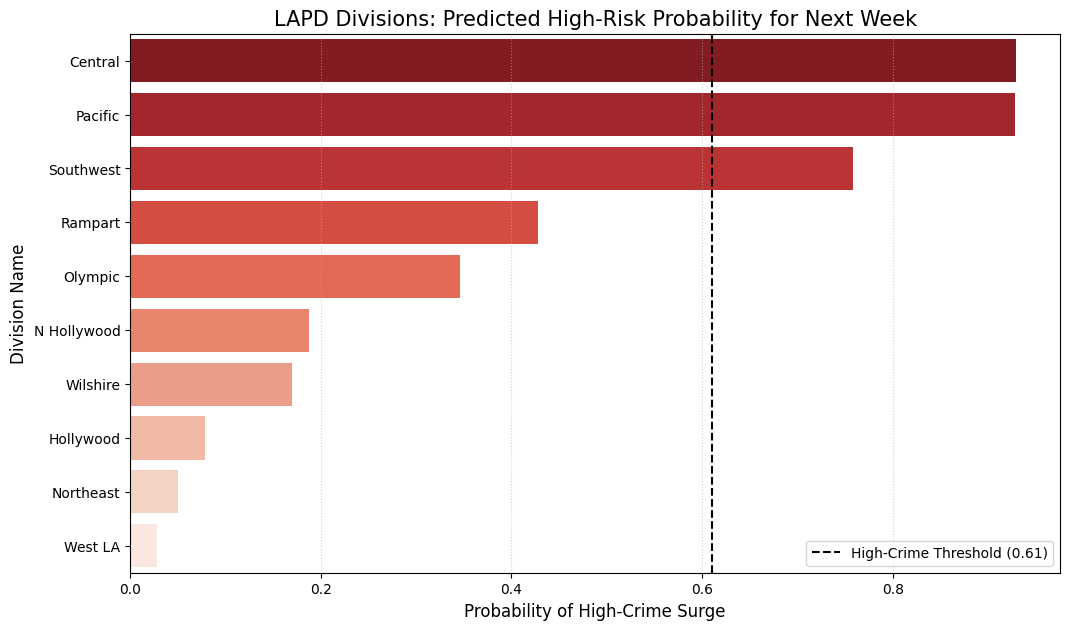

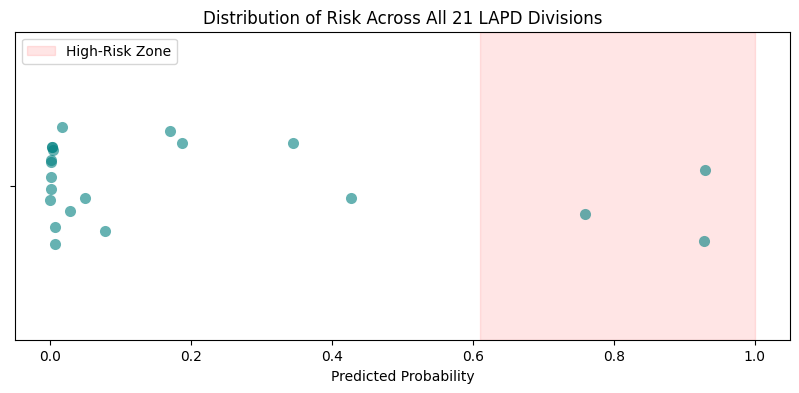

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Top 10 High-Risk Areas (Ranking Visualization)
plt.figure(figsize=(12, 7))
# Colors based on predicted probability to highlight risk levels
colors = sns.color_palette("Reds_r", n_colors=len(pred_df.head(10)))

sns.barplot(
    data=pred_df.head(10), 
    x='predicted_prob_high_next_week', 
    y='AREA NAME', 
    palette=colors
)

# Adding the threshold line to show which areas cross into "High Crime"
plt.axvline(best_threshold, color='black', linestyle='--', label=f'High-Crime Threshold ({best_threshold:.2f})')
plt.title('LAPD Divisions: Predicted High-Risk Probability for Next Week', fontsize=15)
plt.xlabel('Probability of High-Crime Surge', fontsize=12)
plt.ylabel('Division Name', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

# 2. Predicted Probability Gauge (Distribution of Risk)
plt.figure(figsize=(10, 4))
sns.stripplot(
    data=pred_df, 
    x='predicted_prob_high_next_week', 
    color='teal', 
    size=8, 
    jitter=0.2, 
    alpha=0.6
)
plt.title('Distribution of Risk Across All 21 LAPD Divisions')
plt.xlabel('Predicted Probability')
plt.axvspan(best_threshold, 1.0, color='red', alpha=0.1, label='High-Risk Zone')
plt.legend()
plt.show()

In [29]:
# Top-K forced ranking rule
pred_df["rank_next_week_by_model"] = pred_df["predicted_prob_high_next_week"].rank(
    method="dense",
    ascending=False
)

pred_df["predicted_class_top5_rule"] = np.where(
    pred_df["rank_next_week_by_model"] <= TOP_K,
    "High Crime",
    "Low Crime"
)

print("\nTop-5 operational risk areas (forced ranking rule):")
print(
    pred_df[
        ["AREA NAME", "predicted_prob_high_next_week", "rank_next_week_by_model", "predicted_class_top5_rule"]
    ]
    .sort_values("rank_next_week_by_model")
    .head(TOP_K)
)


Top-5 operational risk areas (forced ranking rule):
   AREA NAME  predicted_prob_high_next_week  rank_next_week_by_model  \
0    Central                       0.929153                      1.0   
1    Pacific                       0.928287                      2.0   
2  Southwest                       0.758736                      3.0   
3    Rampart                       0.427737                      4.0   
4    Olympic                       0.345536                      5.0   

  predicted_class_top5_rule  
0                High Crime  
1                High Crime  
2                High Crime  
3                High Crime  
4                High Crime  


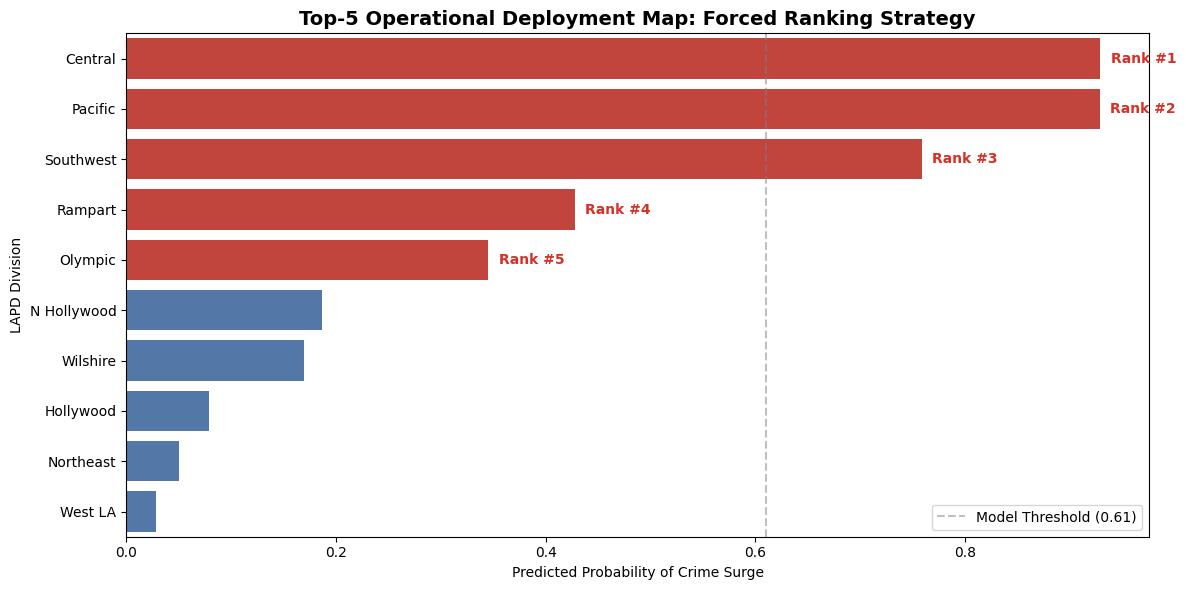

STRATEGIC DEPLOYMENT SUMMARY (NEXT WEEK)
AREA NAME  predicted_prob_high_next_week  rank_next_week_by_model
  Central                       0.929153                      1.0
  Pacific                       0.928287                      2.0
Southwest                       0.758736                      3.0
  Rampart                       0.427737                      4.0
  Olympic                       0.345536                      5.0


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualization: Top-5 Operational Risk Areas (Forced Ranking)
plt.figure(figsize=(12, 6))

# Highlight the Top 5 in a distinct color for urgency
top_5_df = pred_df[pred_df["rank_next_week_by_model"] <= TOP_K].sort_values("rank_next_week_by_model")
other_areas = pred_df[pred_df["rank_next_week_by_model"] > TOP_K]

# Plotting the data
sns.barplot(
    data=pred_df.head(10), # Showing top 10 for context
    x='predicted_prob_high_next_week', 
    y='AREA NAME', 
    palette=['#d73027' if r <= TOP_K else '#4575b4' for r in pred_df.head(10)["rank_next_week_by_model"]]
)

# Visual cues for the 'Top-5 Rule'
plt.axvline(best_threshold, color='grey', linestyle='--', alpha=0.5, label=f'Model Threshold ({best_threshold:.2f})')
plt.title(f'Top-{TOP_K} Operational Deployment Map: Forced Ranking Strategy', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Probability of Crime Surge')
plt.ylabel('LAPD Division')

# Adding text labels for the ranks
for i, row in top_5_df.iterrows():
    plt.text(row['predicted_prob_high_next_week'] + 0.01, i, f"Rank #{int(row['rank_next_week_by_model'])}", 
             va='center', fontweight='bold', color='#d73027')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 2. Operational Summary Table for Report
print(f"STRATEGIC DEPLOYMENT SUMMARY (NEXT WEEK)")
print(top_5_df[["AREA NAME", "predicted_prob_high_next_week", "rank_next_week_by_model"]].to_string(index=False))

In [31]:
metrics_payload = {
    "best_threshold": best_threshold,
    "validation_f1": val_metrics_tuned["f1"],
    "validation_precision": val_metrics_tuned["precision"],
    "validation_recall": val_metrics_tuned["recall"],
    "validation_balanced_acc": val_metrics_tuned["balanced_acc"],
    "validation_roc_auc": val_metrics_tuned["roc_auc"],
    "validation_pr_auc": val_metrics_tuned["pr_auc"],
}

if len(X_test) != 0:
    metrics_payload.update({
        "test_f1": test_metrics["f1"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_balanced_acc": test_metrics["balanced_acc"],
        "test_roc_auc": test_metrics["roc_auc"],
        "test_pr_auc": test_metrics["pr_auc"],
    })

metrics_df = pd.DataFrame([metrics_payload])

# Save predictions and metrics to CSV

pred_df.to_csv("data/next_week_area_risk_predictions.csv", index=False)
metrics_df.to_csv("data/deep_learning_test_metrics.csv", index=False)

# Phase 10 : Comparative Benchmarking: Deep Learning vs. Baselines

In [33]:
# Logistic Regression vs Random Forest vs XGBoost vs GRU vs LSTM

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    auc
)

try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("xgboost not installed. Run: !pip install xgboost")

### REBUILD BASELINE DATA

In [34]:
baseline_df = weekly.copy()

train_df_tab = baseline_df[baseline_df["week_start"] <= train_end].copy()
valid_df_tab = baseline_df[(baseline_df["week_start"] > train_end) & (baseline_df["week_start"] <= valid_end)].copy()
test_df_tab  = baseline_df[baseline_df["week_start"] > valid_end].copy()

X_train_tab = train_df_tab[feature_cols].copy()
y_train_tab = train_df_tab[target_col].astype(int).copy()

X_valid_tab = valid_df_tab[feature_cols].copy()
y_valid_tab = valid_df_tab[target_col].astype(int).copy()

X_test_tab = test_df_tab[feature_cols].copy()
y_test_tab = test_df_tab[target_col].astype(int).copy()

print("Baseline train/valid/test shapes:")
print(X_train_tab.shape, X_valid_tab.shape, X_test_tab.shape)


Baseline train/valid/test shapes:
(4389, 78) (735, 78) (336, 78)


### HELPERS

In [36]:
def find_best_threshold_general(y_true, probs):
    thresholds = np.arange(0.10, 0.91, 0.01)
    best_t = 0.50
    best_score = -1

    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        rec = recall_score(y_true, preds, zero_division=0)
        score = f1 + 0.15 * rec

        if score > best_score:
            best_score = score
            best_t = t

    return best_t, best_score

def evaluate_probs(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    metrics = {
        "Accuracy": accuracy_score(y_true, preds),
        "F1": f1_score(y_true, preds, zero_division=0),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "Balanced_Acc": balanced_accuracy_score(y_true, preds),
        "ROC_AUC": roc_auc_score(y_true, probs),
        "PR_AUC": average_precision_score(y_true, probs),
    }
    return metrics, preds

def fit_eval_baseline(model_name, model_obj, X_train, y_train, X_valid, y_valid, X_test, y_test):
    model_obj.fit(X_train, y_train)

    valid_probs = model_obj.predict_proba(X_valid)[:, 1]
    threshold, _ = find_best_threshold_general(y_valid, valid_probs)

    test_probs = model_obj.predict_proba(X_test)[:, 1]
    test_metrics, test_preds = evaluate_probs(y_test, test_probs, threshold)

    row = {
        "Model": model_name,
        "Threshold": threshold,
        **test_metrics
    }
    return row, test_probs, test_preds

### TRAIN BASELINE MODELS

In [37]:
baseline_models = []

log_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])
baseline_models.append(("Logistic Regression", log_reg))

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])
baseline_models.append(("Random Forest", rf_model))

if xgb_available:
    neg = (y_train_tab == 0).sum()
    pos = (y_train_tab == 1).sum()
    scale_pos_weight = neg / max(pos, 1)

    xgb_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=500,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1
        ))
    ])
    baseline_models.append(("XGBoost", xgb_model))

baseline_rows = []
baseline_prob_store = {}
baseline_thresholds = {}

for model_name, baseline_model in baseline_models:
    row, probs, preds = fit_eval_baseline(
        model_name, baseline_model,
        X_train_tab, y_train_tab,
        X_valid_tab, y_valid_tab,
        X_test_tab, y_test_tab
    )
    baseline_rows.append(row)
    baseline_prob_store[model_name] = probs
    baseline_thresholds[model_name] = row["Threshold"]

results_df = pd.DataFrame(baseline_rows)

print("\nBaseline test results:")
print(results_df.to_string(index=False))


Baseline test results:
              Model  Threshold  Accuracy       F1  Precision   Recall  Balanced_Acc  ROC_AUC   PR_AUC
Logistic Regression       0.73  0.851190 0.683544   0.782609 0.606742      0.773006 0.868444 0.803963
      Random Forest       0.42  0.866071 0.689655   0.892857 0.561798      0.768753 0.877633 0.816563
            XGBoost       0.33  0.863095 0.708861   0.811594 0.629213      0.788291 0.874630 0.814119


### LSTM MODEL


In [38]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=96, num_layers=2, dropout=0.30):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x_seq):
        out, _ = self.lstm(x_seq)
        last_hidden = out[:, -1, :]
        logits = self.head(last_hidden).squeeze(1)
        return logits

def evaluate_lstm(model_obj, loader, threshold=0.5):
    model_obj.eval()
    all_probs, all_true = [], []

    with torch.no_grad():
        for x_seq, x_area, y in loader:
            x_seq = x_seq.to(device)
            logits = model_obj(x_seq)
            probs = torch.sigmoid(logits)

            all_probs.extend(probs.cpu().numpy())
            all_true.extend(y.numpy())

    all_probs = np.array(all_probs)
    all_true = np.array(all_true)
    preds = (all_probs >= threshold).astype(int)

    metrics = {
        "Accuracy": accuracy_score(all_true, preds),
        "F1": f1_score(all_true, preds, zero_division=0),
        "Precision": precision_score(all_true, preds, zero_division=0),
        "Recall": recall_score(all_true, preds, zero_division=0),
        "Balanced_Acc": balanced_accuracy_score(all_true, preds),
        "ROC_AUC": roc_auc_score(all_true, all_probs),
        "PR_AUC": average_precision_score(all_true, all_probs),
    }
    return metrics, all_true, all_probs

def get_gru_probs(gru_model_obj, loader):
    gru_model_obj.eval()
    probs, y_true = [], []

    with torch.no_grad():
        for x_seq, x_area, y in loader:
            x_seq = x_seq.to(device)
            x_area = x_area.to(device)
            logits = gru_model_obj(x_seq, x_area)
            p = torch.sigmoid(logits).cpu().numpy()
            probs.extend(p)
            y_true.extend(y.numpy())

    return np.array(y_true), np.array(probs)

def get_lstm_probs(lstm_model_obj, loader):
    lstm_model_obj.eval()
    probs, y_true = [], []

    with torch.no_grad():
        for x_seq, x_area, y in loader:
            x_seq = x_seq.to(device)
            logits = lstm_model_obj(x_seq)
            p = torch.sigmoid(logits).cpu().numpy()
            probs.extend(p)
            y_true.extend(y.numpy())

    return np.array(y_true), np.array(probs)

seq_input_size = train_ds.X_seq.shape[2]

lstm_model = LSTMClassifier(
    input_size=seq_input_size,
    hidden_size=96,
    num_layers=2,
    dropout=0.30
).to(device)

y_train_seq = train_ds.y.cpu().numpy()
neg_count = (y_train_seq == 0).sum()
pos_count = (y_train_seq == 1).sum()
pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32).to(device)

lstm_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
lstm_optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
lstm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    lstm_optimizer, mode="max", factor=0.5, patience=3
)

best_lstm_state = None
best_lstm_f1 = -1
patience = 10
patience_counter = 0
epochs = 30

for epoch in range(1, epochs + 1):
    lstm_model.train()
    total_loss = 0

    for x_seq, x_area, y in train_loader:
        x_seq = x_seq.to(device)
        y = y.to(device)

        lstm_optimizer.zero_grad()
        logits = lstm_model(x_seq)
        loss = lstm_criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        lstm_optimizer.step()

        total_loss += loss.item()

    val_metrics, _, _ = evaluate_lstm(lstm_model, valid_loader, threshold=0.5)
    lstm_scheduler.step(val_metrics["F1"])

    print(
        f"LSTM Epoch {epoch:02d} | "
        f"Train Loss: {total_loss / max(len(train_loader), 1):.4f} | "
        f"Val F1: {val_metrics['F1']:.4f} | "
        f"Val Recall: {val_metrics['Recall']:.4f} | "
        f"Val PR-AUC: {val_metrics['PR_AUC']:.4f} | "
        f"Val ROC-AUC: {val_metrics['ROC_AUC']:.4f}"
    )

    if val_metrics["F1"] > best_lstm_f1:
        best_lstm_f1 = val_metrics["F1"]
        best_lstm_state = copy.deepcopy(lstm_model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("LSTM early stopping triggered.")
        break

if best_lstm_state is not None:
    lstm_model.load_state_dict(best_lstm_state)

LSTM Epoch 01 | Train Loss: 0.7273 | Val F1: 0.5857 | Val Recall: 0.8261 | Val PR-AUC: 0.6669 | Val ROC-AUC: 0.8474
LSTM Epoch 02 | Train Loss: 0.4824 | Val F1: 0.6169 | Val Recall: 0.8315 | Val PR-AUC: 0.6687 | Val ROC-AUC: 0.8537
LSTM Epoch 03 | Train Loss: 0.4946 | Val F1: 0.6286 | Val Recall: 0.8370 | Val PR-AUC: 0.6753 | Val ROC-AUC: 0.8611
LSTM Epoch 04 | Train Loss: 0.4733 | Val F1: 0.6405 | Val Recall: 0.7989 | Val PR-AUC: 0.6799 | Val ROC-AUC: 0.8563
LSTM Epoch 05 | Train Loss: 0.4706 | Val F1: 0.6418 | Val Recall: 0.7935 | Val PR-AUC: 0.6501 | Val ROC-AUC: 0.8509
LSTM Epoch 06 | Train Loss: 0.4134 | Val F1: 0.6259 | Val Recall: 0.7500 | Val PR-AUC: 0.6337 | Val ROC-AUC: 0.8557
LSTM Epoch 07 | Train Loss: 0.4414 | Val F1: 0.6205 | Val Recall: 0.7554 | Val PR-AUC: 0.6406 | Val ROC-AUC: 0.8534
LSTM Epoch 08 | Train Loss: 0.4010 | Val F1: 0.6296 | Val Recall: 0.7391 | Val PR-AUC: 0.6543 | Val ROC-AUC: 0.8605
LSTM Epoch 09 | Train Loss: 0.4060 | Val F1: 0.6260 | Val Recall: 0.6685

### GRU + LSTM TEST PROBABILITIES

In [39]:
# gru_model = model

gru_threshold = float(best_threshold)

lstm_val_metrics, yv_lstm, pv_lstm = evaluate_lstm(lstm_model, valid_loader, threshold=0.5)
lstm_best_threshold, _ = find_best_threshold_general(yv_lstm, pv_lstm)

y_true_gru, gru_probs = get_gru_probs(gru_model, test_loader)
y_true_lstm, lstm_probs = get_lstm_probs(lstm_model, test_loader)

gru_metrics, _ = evaluate_probs(y_true_gru, gru_probs, gru_threshold)
lstm_metrics, _ = evaluate_probs(y_true_lstm, lstm_probs, lstm_best_threshold)

### FINAL COMPARISON TABLE

In [52]:
comparison_rows = []

for _, row in results_df.iterrows():
    comparison_rows.append({
        "Model": row["Model"],
        "Threshold": row["Threshold"],
        "Accuracy": row["Accuracy"],
        "F1": row["F1"],
        "Precision": row["Precision"],
        "Recall": row["Recall"],
        "Balanced_Acc": row["Balanced_Acc"],
        "ROC_AUC": row["ROC_AUC"],
        "PR_AUC": row["PR_AUC"],
    })

comparison_rows.append({
    "Model": "GRU",
    "Threshold": gru_threshold,
    **gru_metrics
})

comparison_rows.append({
    "Model": "LSTM",
    "Threshold": lstm_best_threshold,
    **lstm_metrics
})

comparison_all_df = pd.DataFrame(comparison_rows).sort_values(
    ["F1", "ROC_AUC"], ascending=False
).reset_index(drop=True)

print("\nFINAL MODEL COMPARISON")
print(comparison_all_df.to_string(index=False))


FINAL MODEL COMPARISON
              Model  Threshold  Accuracy       F1  Precision   Recall  Balanced_Acc  ROC_AUC   PR_AUC
            XGBoost       0.33  0.863095 0.708861   0.811594 0.629213      0.788291 0.874630 0.814119
                GRU       0.61  0.869048 0.694444   0.909091 0.561798      0.770777 0.837283 0.759790
      Random Forest       0.42  0.866071 0.689655   0.892857 0.561798      0.768753 0.877633 0.816563
Logistic Regression       0.73  0.851190 0.683544   0.782609 0.606742      0.773006 0.868444 0.803963
               LSTM       0.49  0.821429 0.491525   1.000000 0.325843      0.662921 0.853432 0.768865


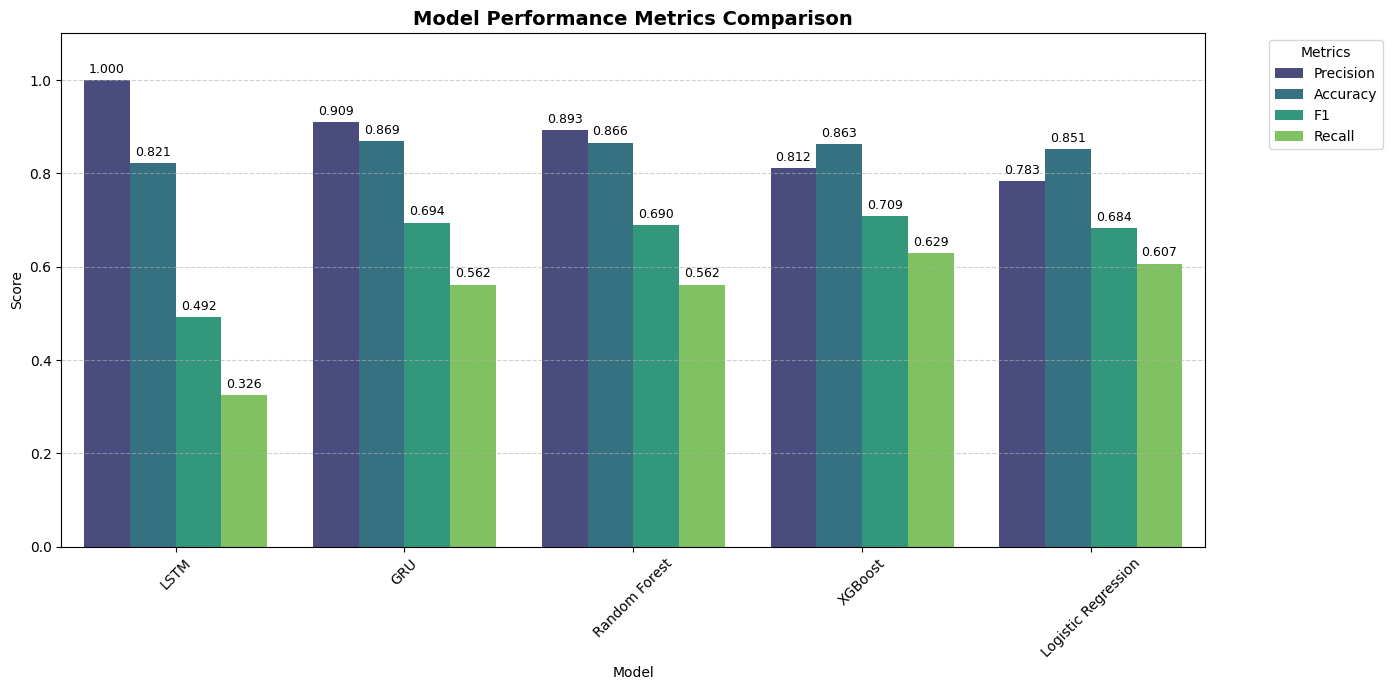

In [53]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
df_long = comparison_all_df.melt(
    id_vars="Model", 
    value_vars=metrics, 
    var_name="Metric", 
    value_name="Score"
)

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_long.sort_values("Score", ascending=False),
    x="Model",
    y="Score",
    hue="Metric",
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.xticks(rotation=45)
plt.title("Model Performance Metrics Comparison", fontsize=14, fontweight='bold')
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

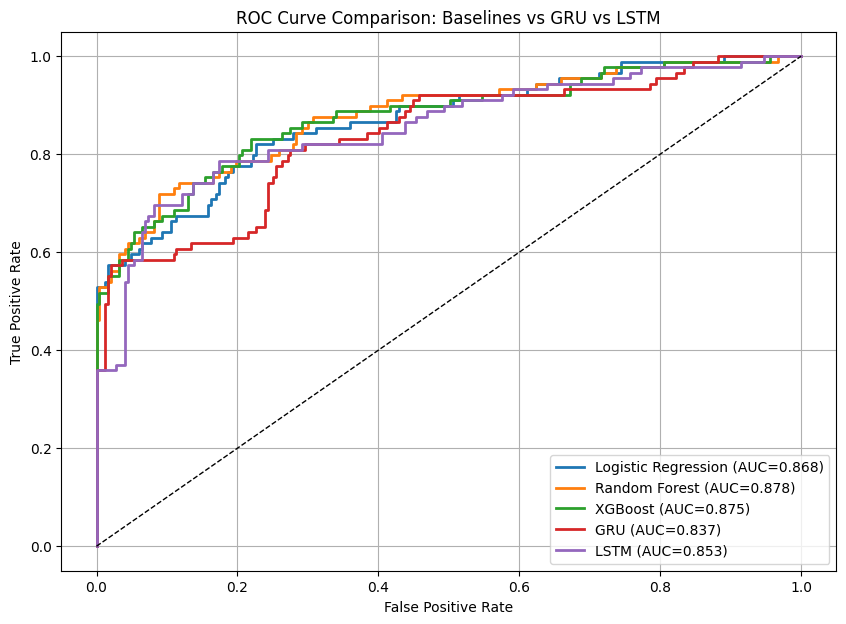

In [54]:
plt.figure(figsize=(10, 7))

for model_name, probs in baseline_prob_store.items():
    fpr, tpr, _ = roc_curve(y_test_tab.values, probs)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={roc_auc_val:.3f})")

fpr, tpr, _ = roc_curve(y_true_gru, gru_probs)
roc_auc_val = auc(fpr, tpr)
plt.plot(fpr, tpr, linewidth=2, label=f"GRU (AUC={roc_auc_val:.3f})")

fpr, tpr, _ = roc_curve(y_true_lstm, lstm_probs)
roc_auc_val = auc(fpr, tpr)
plt.plot(fpr, tpr, linewidth=2, label=f"LSTM (AUC={roc_auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Baselines vs GRU vs LSTM")
plt.legend()
plt.grid(True)
plt.show()